# Telecom	Customer	Churn	Exploratory	Analysis

In [2]:
import pandas as pd

dataset = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
dataset.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 1. What is the overall churn rate in the dataset?

In [4]:
churn_rate = dataset["Churn"].value_counts(normalize=True).mul(100).map(lambda x: f"{x:.2f}%")
churn_rate

Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object

## 2. Does	churn	rate	differ	by	contract	type	(month-to-month	vs.	one/two-year)?

In [5]:
contract_type_churn_rate = pd.crosstab(
    dataset["Contract"],
    dataset["Churn"],
    normalize="index"
).mul(100)

contract_type_churn_rate.map(lambda x: f"{x:.2f}%")

Churn,No,Yes
Contract,,
Month-to-month,57.29%,42.71%
One year,88.73%,11.27%
Two year,97.17%,2.83%


## 3. Is there a relationship between tenure (months	as	a	customer) and churn?

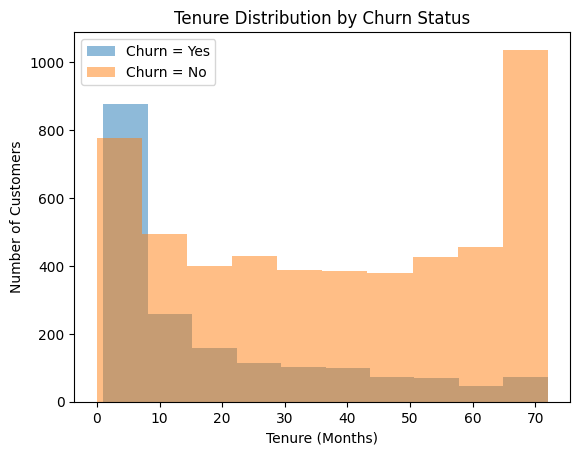

In [6]:
import matplotlib.pyplot as plt

tenure_yes = dataset.loc[dataset["Churn"] == "Yes", "tenure"]
tenure_no = dataset.loc[dataset["Churn"] == "No", "tenure"]

plt.hist(tenure_yes, bins=10, alpha=0.5, label="Churn = Yes")
plt.hist(tenure_no, bins=10, alpha=0.5, label="Churn = No")

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Tenure Distribution by Churn Status")
plt.legend()
plt.show()

In [7]:
dataset["tenure_group"] = pd.cut(
    dataset["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-36 months",
        "37-48 months",
        "49-60 months",
        "61-72 months"
    ]
)

churn_rate = (
    dataset.groupby("tenure_group", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

churn_rate = churn_rate.map(lambda x: f"{x:.2f}%")

print(churn_rate)

tenure_group
0-12 months     47.68%
13-24 months    28.71%
25-36 months    21.63%
37-48 months    19.03%
49-60 months    14.42%
61-72 months     6.61%
Name: Churn, dtype: object


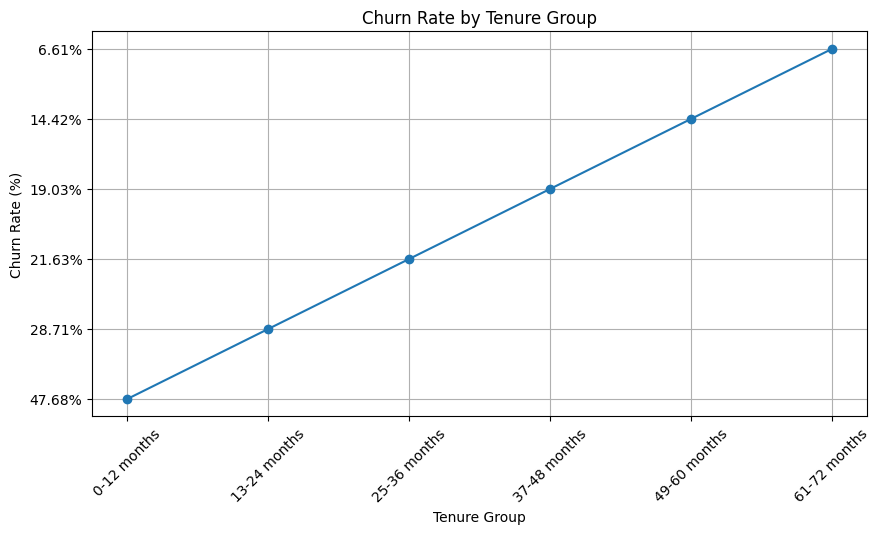

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    churn_rate.index,
    churn_rate.values,
    marker="o"
)

plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure Group")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 4. Which services (e.g. internet type, add-ons) are associated with higher or lower churn?

In [13]:
internet_type_churn_rate = pd.crosstab(
    dataset["InternetService"],
    dataset["Churn"],
    normalize="index"
).mul(100)

phone_service_churn_rate = pd.crosstab(
    dataset["PhoneService"],
    dataset["Churn"],
    normalize="index"
).mul(100)

online_security_churn_rate = pd.crosstab(
    dataset["OnlineSecurity"],
    dataset["Churn"],
    normalize="index"
).mul(100)

online_backup_churn_rate = pd.crosstab(
    dataset["OnlineBackup"],
    dataset["Churn"],
    normalize="index"
).mul(100)

device_protection_churn_rate = pd.crosstab(
    dataset["DeviceProtection"],
    dataset["Churn"],
    normalize="index"
).mul(100)

tech_support_churn_rate = pd.crosstab(
    dataset["TechSupport"],
    dataset["Churn"],
    normalize="index"
).mul(100)

streaming_tv_churn_rate = pd.crosstab(
    dataset["StreamingTV"],
    dataset["Churn"],
    normalize="index"
).mul(100)

streaming_movies_churn_rate = pd.crosstab(
    dataset["StreamingMovies"],
    dataset["Churn"],
    normalize="index"
).mul(100)

print(internet_type_churn_rate.map(lambda x: f"{x:.2f}%"))
print("\n")
print(phone_service_churn_rate.map(lambda x: f"{x:.2f}%"))
print("\n")
print(online_security_churn_rate.map(lambda x: f"{x:.2f}%"))
print("\n")
print(online_backup_churn_rate.map(lambda x: f"{x:.2f}%"))
print("\n")
print(device_protection_churn_rate.map(lambda x: f"{x:.2f}%"))
print("\n")
print(tech_support_churn_rate.map(lambda x: f"{x:.2f}%"))
print("\n")
print(streaming_tv_churn_rate.map(lambda x: f"{x:.2f}%"))
print("\n")
print(streaming_movies_churn_rate.map(lambda x: f"{x:.2f}%"))
print("\n")

Churn                No     Yes
InternetService                
DSL              81.04%  18.96%
Fiber optic      58.11%  41.89%
No               92.60%   7.40%


Churn             No     Yes
PhoneService                
No            75.07%  24.93%
Yes           73.29%  26.71%


Churn                    No     Yes
OnlineSecurity                     
No                   58.23%  41.77%
No internet service  92.60%   7.40%
Yes                  85.39%  14.61%


Churn                    No     Yes
OnlineBackup                       
No                   60.07%  39.93%
No internet service  92.60%   7.40%
Yes                  78.47%  21.53%


Churn                    No     Yes
DeviceProtection                   
No                   60.87%  39.13%
No internet service  92.60%   7.40%
Yes                  77.50%  22.50%


Churn                    No     Yes
TechSupport                        
No                   58.36%  41.64%
No internet service  92.60%   7.40%
Yes                  84.83%  1

## 5. How does monthly charge relate to churn?

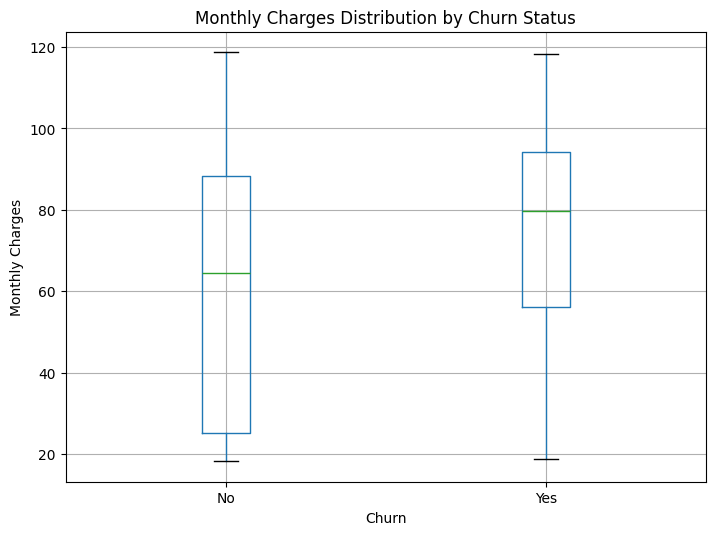

In [11]:
import matplotlib.pyplot as plt

dataset.boxplot(
    column="MonthlyCharges",
    by="Churn",
    figsize=(8, 6)
)

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges Distribution by Churn Status")
plt.suptitle("")

plt.show()

In [12]:
monthly_charge_stats = dataset.groupby("Churn")["MonthlyCharges"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Min="min",
    Max="max"
).round(2)

monthly_charge_stats

,Count,Mean,Median,Q1,Q3,Min,Max
Churn,,,,,,,
No,5174,61.27,64.43,25.10,88.4,18.25,118.75
Yes,1869,74.44,79.65,56.15,94.2,18.85,118.35


# Summary

1. from 7043 customer, 26.54% is churn
2. Month-to-month contract type become the most churn rate among others with 42.71% and the lowest is 'Two year' contract type with only 2.83%
3. Tenure have correlation with the churn rate, the tenure between 0-12 months have more percentage of churn which is 47.68% comapare with 61-72 months only 6.61%
4. for internet service, Fiber optic become categorical with highest churn rate which is 41.89%. customer with phone service have more churn rate which is 26.71% than the one who isn't. the service like online security, online backup, device protection, tech support, streaming tv and streaming movies have the highest churn rate from customer that not use that services. like online security have 41.77%
5. Customers who churn tend to have higher monthly charges than those who remain with the median that approximately 80, compared to approximately 65 from customers who did not churn.